In [125]:
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn, optim
from tqdm import tqdm

## Hyperparameters

In [137]:
HIDDEN = 30
LEARNING_RATE = 4e-3
EPISODES = 1_000

GAMMA = 0.999

## Building Blocks

In [138]:
class Policy(nn.Module):
    def __init__(self, hidden: int):
        super().__init__()
        self.ffw = nn.Sequential(nn.Linear(4, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    def forward(self, x):
        x = self.ffw(x)
        return x

## Training

In [139]:
def rewards_to_returns(rewards: list[float]) -> torch.Tensor:
    returns = deque([])
    R = 0
    for reward in reversed(rewards):
        R = reward + R * GAMMA
        returns.appendleft(R)

    return torch.Tensor(returns)

In [140]:
env = gym.make("CartPole-v1")
policy = Policy(HIDDEN)
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPISODES, eta_min=1e-3
)

In [141]:
step_lengths = []
for episode in tqdm(range(EPISODES)):
    done = False
    state, _ = env.reset(options={"low": -0.15, "high": 0.15})
    log_probs, rewards = [], []
    steps_survived = 0
    while not done:
        logit = policy(torch.tensor(state))
        dist = torch.distributions.Bernoulli(F.sigmoid(logit))
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        state, reward, terminated, truncated, _ = env.step(int(action.item()))
        # Reward Shaping
        reward *= (
            torch.distributions.Normal(loc=0, scale=0.7)
            .log_prob(torch.tensor(state[0]))
            .exp()
            .item()
        )
        rewards.append(reward)
        done = terminated or truncated
        steps_survived += 1

    log_probs = torch.cat(log_probs)
    returns = rewards_to_returns(rewards)

    loss = -torch.sum(log_probs * returns)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    step_lengths.append(steps_survived)

100%|██████████| 1000/1000 [03:30<00:00,  4.76it/s]


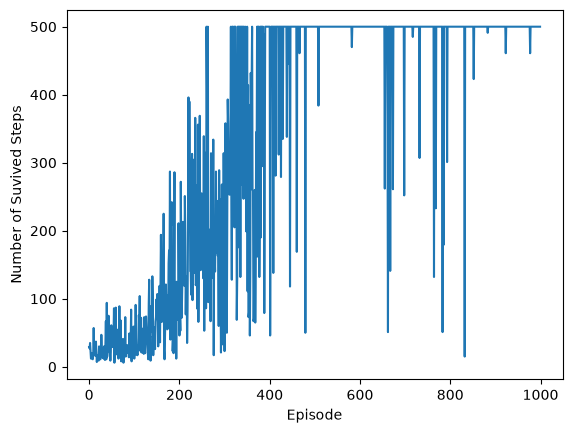

In [142]:
plt.plot(step_lengths)
# plt.yscale("log")
plt.xlabel("Episode")
plt.ylabel("Number of Suvived Steps")
plt.show()

## Simulation

In [152]:
simulation = gym.make("CartPole-v1", render_mode="human", max_episode_steps=500)
state, _ = simulation.reset(options={"low": -0.2, "high": 0.2})

policy.eval()
done = False
steps = 0
while not done:
    with torch.no_grad():
        logit = policy(torch.tensor(state))
    action = int(logit.item() > 0)
    state, _, terminated, truncated, _ = simulation.step(action)
    done = terminated or truncated
    steps += 1

print(f"Survived {steps} steps")
simulation.close()


Survived 500 steps
